# Fairness-Oriented Timetabling

Revenue-maximizing timetabling with fairness awareness. In addition to the
pure revenue objective, this notebook optimizes a weighted combination of
revenue and a fairness index (Jain / Gini / Atkinson) to balance the capacity
allocation across Railway Undertakings (RUs).


## 0. Load Libraries


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from robin.supply.generator.entities import SupplyGenerator
from robin.supply.entities import Supply

from craft import RevenueSimulator, Solution, FairnessMetrics
from craft.mealpy import MealpyTimetabling
from mealpy import FloatVar, GA

## 1. Generate Supply


In [2]:
supply_config_path = Path('../configs/supply_generator/supply_data.yaml')
generator_config_path = Path('../configs/supply_generator/config.yaml')
generator_save_path = Path('../data/results/supply_fairness.yaml')

Path('../data/results').mkdir(parents=True, exist_ok=True)

generator = SupplyGenerator.from_yaml(
    path_config_supply=supply_config_path,
    path_config_generator=generator_config_path,
)

generator.generate(
    n_services=25,
    output_path=generator_save_path,
    seed=42,
    progress_bar=True,
    without_conflicts=False,
)

print(f'Generated {len(generator.services)} services')

Generating services all: 100%|██████████| 25/25 [00:00<00:00, 462.88service/s]

Generated 25 services


## 2. Load Supply and Generate Revenue Behavior


In [3]:
supply = Supply.from_yaml(path=str(generator_save_path))
print(f'Loaded {len(supply.services)} services')

revenue_simulator = RevenueSimulator(supply=supply)
revenue_behavior = revenue_simulator.simulate_revenue(alpha=2/3)

print(f'Revenue behavior computed for {len(revenue_behavior)} services')

Loaded 25 services
Revenue behavior computed for 25 services


## 3. Initialize Timetabling Problem


In [4]:
timetabling = MealpyTimetabling(
    requested_services=supply.services,
    revenue_behavior=revenue_behavior,
    safe_headway=10,
    max_stop_time=10,
)

print(f'Problem initialized with {timetabling.n_services} services')

Problem initialized with 25 services


## 4. Baseline Fairness Metrics

Compute the fairness metrics on the unoptimized (reference) schedule as a
baseline. The Jain index is in ``[0, 1]`` (1 = perfectly fair), while Gini and
Atkinson are inequality measures (0 = perfectly fair).


In [5]:
fairness = FairnessMetrics()

service_revenues = timetabling.revenue_calculator.service_revenues
revenue_values = [r['revenue'] for r in service_revenues.values()]

jain = fairness.jain_index(revenue_values)
gini = fairness.gini_coefficient(revenue_values)
atkinson = fairness.atkinson_index(revenue_values)

print('=== Baseline Fairness Metrics ===')
print(f'Jain index:     {jain:.4f}  (1 = perfectly fair)')
print(f'Gini coefficient: {gini:.4f}  (0 = perfectly fair)')
print(f'Atkinson index:  {atkinson:.4f}  (0 = perfectly fair)')

=== Baseline Fairness Metrics ===
Jain index:     0.8804  (1 = perfectly fair)
Gini coefficient: 0.1500  (0 = perfectly fair)
Atkinson index:  0.0000  (0 = perfectly fair)


## 5. Fairness-Aware Optimization

The objective combines normalized revenue and a fairness index with weights
``alpha`` (revenue) and ``beta`` (fairness). A higher ``beta`` pushes the
optimizer toward a more equitable capacity allocation across RUs.


In [6]:
alpha = 0.7   # revenue weight
beta = 0.3    # fairness weight


def fairness_objective(solution):
    revenue = timetabling.objective_function(solution)
    schedule = timetabling.get_heuristic_schedule()
    fair_idx, _ = FairnessMetrics.jains_fairness_index(
        schedule, timetabling.capacities, revenue_behavior,
    )
    return alpha * revenue / 1e3 + beta * fair_idx * 100


bounds = [FloatVar(lb=lb, ub=ub) for lb, ub in timetabling.boundaries.real]
problem = {
    'obj_func': fairness_objective,
    'bounds': bounds,
    'minmax': 'max',
    'verbose': False,
}

model = GA.BaseGA(epoch=50, pop_size=20, pc=0.9, pm=0.01)
print('Starting fairness-aware GA optimization...')
model.solve(problem, seed=42)
print(f'Best fitness: {model.g_best.target.fitness}')

2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=50, pop_size=20, pc=0.9, pm=0.01)
2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 30.298862163511593, Global best: 30.298862163511593, Runtime: 0.02821 seconds


Starting fairness-aware GA optimization...


2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 30.31671110561351, Global best: 30.31671110561351, Runtime: 0.03089 seconds
2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 30.313845768989836, Global best: 30.31671110561351, Runtime: 0.02757 seconds
2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 30.314448880954803, Global best: 30.31671110561351, Runtime: 0.02754 seconds
2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 30.31530466933076, Global best: 30.31671110561351, Runtime: 0.02751 seconds
2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 6, Current best: 30.31682349102452, Global best: 30.31682349102452, Runtime: 0.02666 seconds
2026/06/18 04:12:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch:

Best fitness: 30.368920661155446


## 6. Compare Results

Re-evaluate the fairness metrics after optimization and compare against the
baseline.


In [7]:
best_position = model.g_best.solution
schedule = timetabling.get_heuristic_schedule()

solution = Solution(real=best_position, discrete=schedule)
updated_services = timetabling.update_supply(str(generator_save_path), solution)

service_revenues_opt = timetabling.revenue_calculator.service_revenues
revenue_values_opt = [r['revenue'] for r in service_revenues_opt.values()]

jain_opt = fairness.jain_index(revenue_values_opt)
gini_opt = fairness.gini_coefficient(revenue_values_opt)
atkinson_opt = fairness.atkinson_index(revenue_values_opt)

print('=== Fairness Comparison ===')
print(f'Jain index:      {jain:.4f} -> {jain_opt:.4f}')
print(f'Gini coefficient: {gini:.4f} -> {gini_opt:.4f}')
print(f'Atkinson index:  {atkinson:.4f} -> {atkinson_opt:.4f}')
print(f'Scheduled services: {sum(schedule)}/{len(schedule)}')

=== Fairness Comparison ===
Jain index:      0.8804 -> 0.9213
Gini coefficient: 0.1500 -> 0.1158
Atkinson index:  0.0000 -> 0.0000
Scheduled services: 23/25


## 7. Convergence


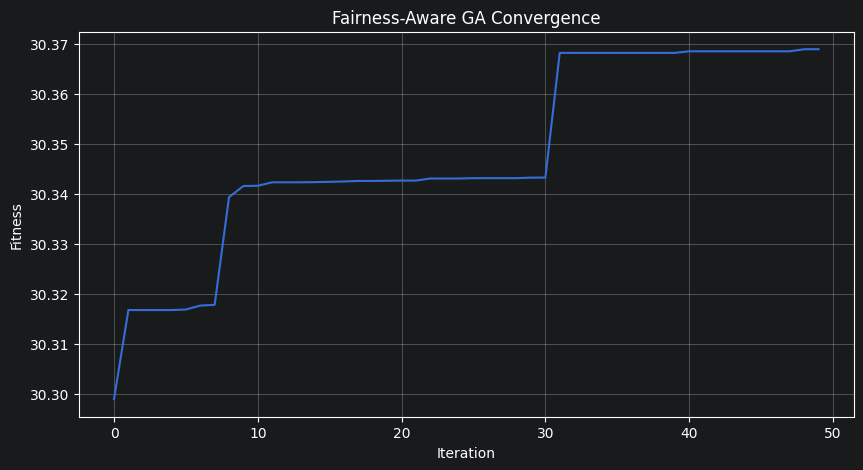

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot([data.target.fitness for data in model.history.list_global_best])
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('Fairness-Aware GA Convergence')
plt.grid(True)
plt.show()